In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

zip_path = "/content/drive/MyDrive/VeritasAI/dataset/Celeb-DF-v2.zip"

print(os.path.exists(zip_path))

False


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

zip_path = "/content/drive/MyDrive/VeritasAI/dataset/Celeb-DF-v2.zip"

print(os.path.exists(zip_path))

True


In [ ]:
!unzip -q "/content/drive/MyDrive/VeritasAI/dataset/Celeb-DF-v2.zip" -d "/content/celebdf"

In [ ]:
import os

print(os.path.exists("/content/celebdf"))

True


In [ ]:
import os

for root, dirs, files in os.walk("/content/celebdf"):
    print("ROOT:", root)
    print("DIRS:", dirs[:10])
    print("FILES:", files[:10])
    break

ROOT: /content/celebdf
DIRS: ['Celeb-real', 'YouTube-real', 'Celeb-synthesis']
FILES: ['List_of_testing_videos.txt']


In [ ]:
import os

for folder in [
    "/content/celebdf/Celeb-real",
    "/content/celebdf/YouTube-real",
    "/content/celebdf/Celeb-synthesis"
]:
    print(folder)
    print("Files:", len(os.listdir(folder)))
    print()

/content/celebdf/Celeb-real
Files: 590

/content/celebdf/YouTube-real
Files: 300

/content/celebdf/Celeb-synthesis
Files: 5639



In [ ]:
import os
import random

random.seed(42)

real_videos = []

for folder in [
    "/content/celebdf/Celeb-real",
    "/content/celebdf/YouTube-real"
]:
    files = [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.endswith(".mp4")
    ]
    real_videos.extend(files)

fake_videos = [
    os.path.join("/content/celebdf/Celeb-synthesis", f)
    for f in os.listdir("/content/celebdf/Celeb-synthesis")
    if f.endswith(".mp4")
]

sample_real = random.sample(real_videos, 100)
sample_fake = random.sample(fake_videos, 100)

print("Real:", len(sample_real))
print("Fake:", len(sample_fake))

Real: 100
Fake: 100


In [ ]:
import os

os.makedirs("/content/eval_frames/real", exist_ok=True)
os.makedirs("/content/eval_frames/fake", exist_ok=True)

In [ ]:
import cv2
import os

def extract_middle_frame(video_path, output_path):
    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return False

    middle = total_frames // 2

    cap.set(cv2.CAP_PROP_POS_FRAMES, middle)

    success, frame = cap.read()

    if success:
        cv2.imwrite(output_path, frame)

    cap.release()
    return success


# REAL
count = 0
for video in sample_real:
    out_file = f"/content/eval_frames/real/real_{count}.jpg"
    extract_middle_frame(video, out_file)
    count += 1

# FAKE
count = 0
for video in sample_fake:
    out_file = f"/content/eval_frames/fake/fake_{count}.jpg"
    extract_middle_frame(video, out_file)
    count += 1

print("Done")

Done


In [ ]:
import os

print("Real frames :", len(os.listdir("/content/eval_frames/real")))
print("Fake frames :", len(os.listdir("/content/eval_frames/fake")))

Real frames : 100
Fake frames : 100


/content/eval_frames/real/real_76.jpg


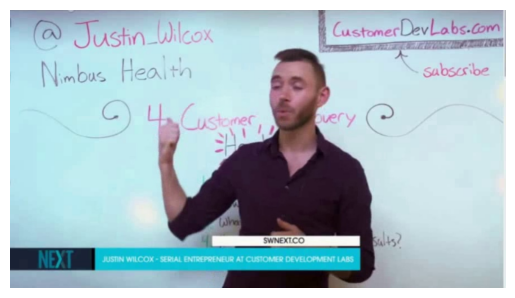

In [ ]:
from PIL import Image
import random
import matplotlib.pyplot as plt
import os

img_path = random.choice(
    [os.path.join("/content/eval_frames/real", f)
     for f in os.listdir("/content/eval_frames/real")]
)

print(img_path)

img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")
plt.show()

/content/eval_frames/real/real_76.jpg


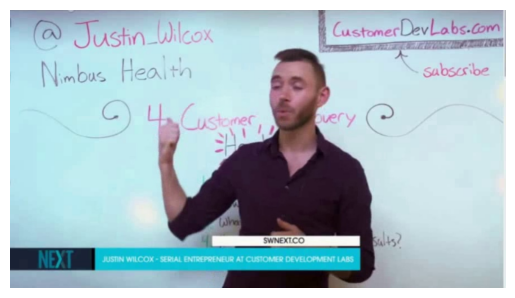

In [ ]:
from PIL import Image
import random
import matplotlib.pyplot as plt
import os

img_path = random.choice(
    [os.path.join("/content/eval_frames/real", f)
     for f in os.listdir("/content/eval_frames/real")]
)

print(img_path)

img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
import tensorflow as tf

MODEL_PATH = "/content/drive/MyDrive/VeritasAI/models/veritas_xception_v2_finetuned.keras"

model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded")

Model loaded


In [ ]:
import cv2
import numpy as np

IMG_SIZE = (299, 299)

def predict_image(img_path):
    img = cv2.imread(img_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, IMG_SIZE)

    img = tf.keras.applications.xception.preprocess_input(
        img.astype(np.float32)
    )

    img = np.expand_dims(img, axis=0)

    prob = float(model.predict(img, verbose=0)[0][0])

    return prob

In [ ]:
import os

y_true = []
y_pred = []

# REAL = 1
real_dir = "/content/eval_frames/real"

for file in os.listdir(real_dir):
    path = os.path.join(real_dir, file)

    prob = predict_image(path)

    pred = 1 if prob >= 0.5 else 0

    y_true.append(1)
    y_pred.append(pred)

# FAKE = 0
fake_dir = "/content/eval_frames/fake"

for file in os.listdir(fake_dir):
    path = os.path.join(fake_dir, file)

    prob = predict_image(path)

    pred = 1 if prob >= 0.5 else 0

    y_true.append(0)
    y_pred.append(pred)

print("Finished")

Finished


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

cm = confusion_matrix(y_true, y_pred)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)

print("\nConfusion Matrix")
print(cm)

Accuracy : 0.5
Precision: 0.5
Recall   : 1.0
F1 Score : 0.6666666666666666

Confusion Matrix
[[  0 100]
 [  0 100]]


In [ ]:
print(y_prob[:20])

NameError: name 'y_prob' is not defined

In [ ]:
%whos


Variable               Type             Data/Info
-------------------------------------------------
IMG_SIZE               tuple            n=2
Image                  module           <module 'PIL.Image' from <...>t-packages/PIL/Image.py'>
MODEL_PATH             str              /content/drive/MyDrive/Ve<...>eption_v2_finetuned.keras
acc                    float            0.5
accuracy_score         function         <function accuracy_score at 0x78bae492f100>
cm                     ndarray          2x2: 4 elems, type `int64`, 32 bytes
confusion_matrix       function         <function confusion_matrix at 0x78bae492f240>
count                  int              100
cv2                    module           <module 'cv2' (<google.co<...>ject at 0x78bbcbfd9b80>)>
dirs                   list             n=3
drive                  module           <module 'google.colab.dri<...>s/google/colab/drive.py'>
extract_middle_frame   function         <function extract_middle_frame at 0x78bbcbfed080>
f1 

In [ ]:
print(set(y_pred))


{1}


In [ ]:
predict_image

<function __main__.predict_image(img_path)>

In [ ]:
import inspect
print(inspect.getsource(predict_image))

def predict_image(img_path):
    img = cv2.imread(img_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, IMG_SIZE)

    img = tf.keras.applications.xception.preprocess_input(
        img.astype(np.float32)
    )

    img = np.expand_dims(img, axis=0)

    prob = float(model.predict(img, verbose=0)[0][0])

    return prob



In [ ]:
for img_path in [
    "/content/eval_frames/real/real_0.jpg",
    "/content/eval_frames/real/real_1.jpg",
    "/content/eval_frames/fake/fake_0.jpg",
    "/content/eval_frames/fake/fake_1.jpg"
]:
    pred, prob = predict_image(img_path)
    print(img_path, pred, prob)

TypeError: cannot unpack non-iterable float object

In [ ]:
print(set(y_pred))

{1}


In [ ]:
probs = []

for img_path in [
    "/content/eval_frames/real/real_0.jpg",
    "/content/eval_frames/real/real_1.jpg",
    "/content/eval_frames/fake/fake_0.jpg",
    "/content/eval_frames/fake/fake_1.jpg",
]:
    p = predict_image(img_path)
    probs.append(p)
    print(img_path, p)

print("min =", min(probs))
print("max =", max(probs))

/content/eval_frames/real/real_0.jpg 1.0
/content/eval_frames/real/real_1.jpg 1.0
/content/eval_frames/fake/fake_0.jpg 1.0
/content/eval_frames/fake/fake_1.jpg 0.9999103546142578
min = 0.9999103546142578
max = 1.0


In [ ]:
real_probs = []

for file in os.listdir("/content/eval_frames/real")[:20]:
    p = predict_image(os.path.join("/content/eval_frames/real", file))
    real_probs.append(p)

print("min =", min(real_probs))
print("max =", max(real_probs))
print("mean =", np.mean(real_probs))

min = 0.9790757894515991
max = 1.0
mean = 0.9976773947477341


In [27]:
real_probs = []
fake_probs = []

for file in os.listdir("/content/eval_frames/real")[:20]:
    real_probs.append(
        predict_image(os.path.join("/content/eval_frames/real", file))
    )

for file in os.listdir("/content/eval_frames/fake")[:20]:
    fake_probs.append(
        predict_image(os.path.join("/content/eval_frames/fake", file))
    )

print("REAL mean:", np.mean(real_probs))
print("FAKE mean:", np.mean(fake_probs))

REAL mean: 0.9976773947477341
FAKE mean: 0.9991549521684646
